# Exploratory Data Analysis — Credit Card Default Dataset

## Objective

This notebook performs exploratory data analysis on the raw credit-card
default dataset to understand:

- Dataset structure and data quality
- Target-variable distribution
- Categorical and numerical features
- Repayment-status behavior
- Bill and payment patterns
- Distributions and outliers
- Relationships between features and default
- Potential feature-engineering opportunities

The findings from this analysis will guide the preprocessing and
feature-engineering pipeline for the ML Model Health Monitoring System.

In [4]:
import sys

print(sys.executable)

d:\Minor_Project_7th\.venv\Scripts\python.exe


In [5]:
import xlrd

print("xlrd version:", xlrd.__version__)

xlrd version: 2.0.2


## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Raw Dataset

We use the original `.xls` file from the `data/raw/` directory.

The raw dataset is kept unchanged because it is the source of truth for
EDA and subsequent preprocessing decisions.

In [7]:
# Project root
PROJECT_ROOT = Path("..")

# Raw dataset path
RAW_FILE = PROJECT_ROOT / "data" / "raw" / "default of credit card clients.xls"

# Load dataset
df = pd.read_excel(RAW_FILE, header=1)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (30000, 25)


## 3. Initial Dataset Inspection

Before performing detailed statistical and visual analysis, we inspect
the structure of the dataset, including its dimensions, columns, data
types, and sample observations.

In [8]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
df.shape

(30000, 25)

In [10]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

## 4. Data Quality Assessment

We assess missing values and duplicate records before proceeding with
statistical and visual analysis.

No values are modified during EDA. Any preprocessing decisions will be
made after the exploratory analysis.

In [12]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_summary

,missing_count,missing_percentage
ID,0,0.0
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


In [13]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [14]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


## 5. Descriptive Statistics

Descriptive statistics are used to understand the central tendency,
dispersion, and range of the numerical variables.

Because several variables may be highly skewed, these statistics will
later be complemented with visualizations.

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## 6. Target Variable Analysis

The target variable represents whether a customer defaulted on their
credit-card payment in the following month.

We analyze its distribution to understand class balance and identify
potential class-imbalance considerations for model development.

In [16]:
target = "default payment next month"

target_counts = df[target].value_counts().sort_index()

print(target_counts)

default payment next month
0    23364
1     6636
Name: count, dtype: int64


In [17]:
target_percent = df[target].value_counts(normalize=True).sort_index() * 100

print(target_percent.round(2))

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64


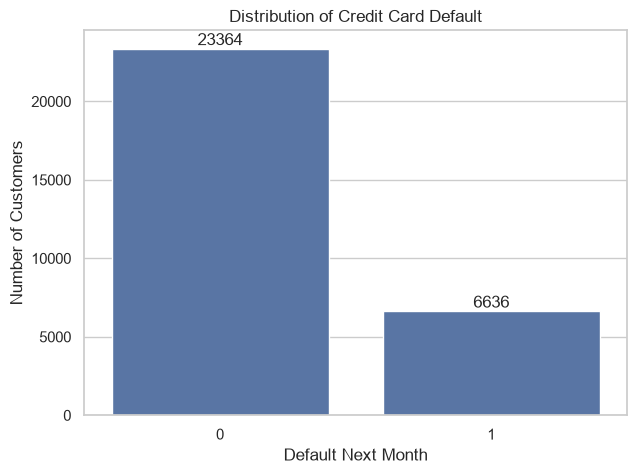

In [18]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x=target)

plt.title("Distribution of Credit Card Default")
plt.xlabel("Default Next Month")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

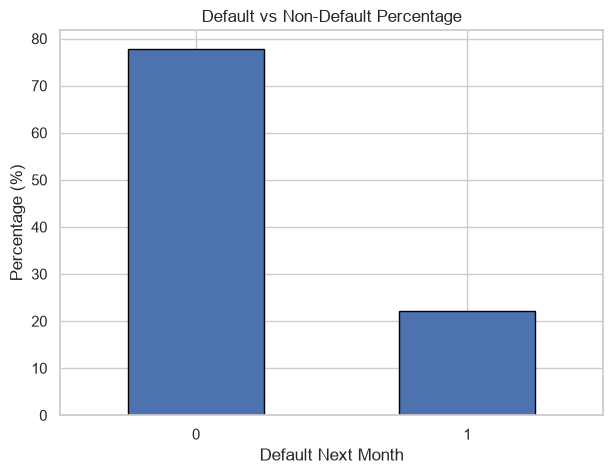

In [19]:
plt.figure(figsize=(7, 5))

target_percent.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Default vs Non-Default Percentage")
plt.xlabel("Default Next Month")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.show()

### Target Analysis Findings

- The dataset contains 30,000 customer records.
- Approximately 77.88% of customers belong to the non-default class.
- Approximately 22.12% belong to the default class.
- The target is moderately imbalanced.
- Model evaluation should therefore not rely only on accuracy; precision,
  recall, F1-score and ROC-AUC should also be considered.

## 7. Categorical Feature Analysis

The variables `SEX`, `EDUCATION`, and `MARRIAGE` are represented using
numeric codes but should be treated as categorical variables.

We examine their category frequencies and their relationship with the
default target.

In [20]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


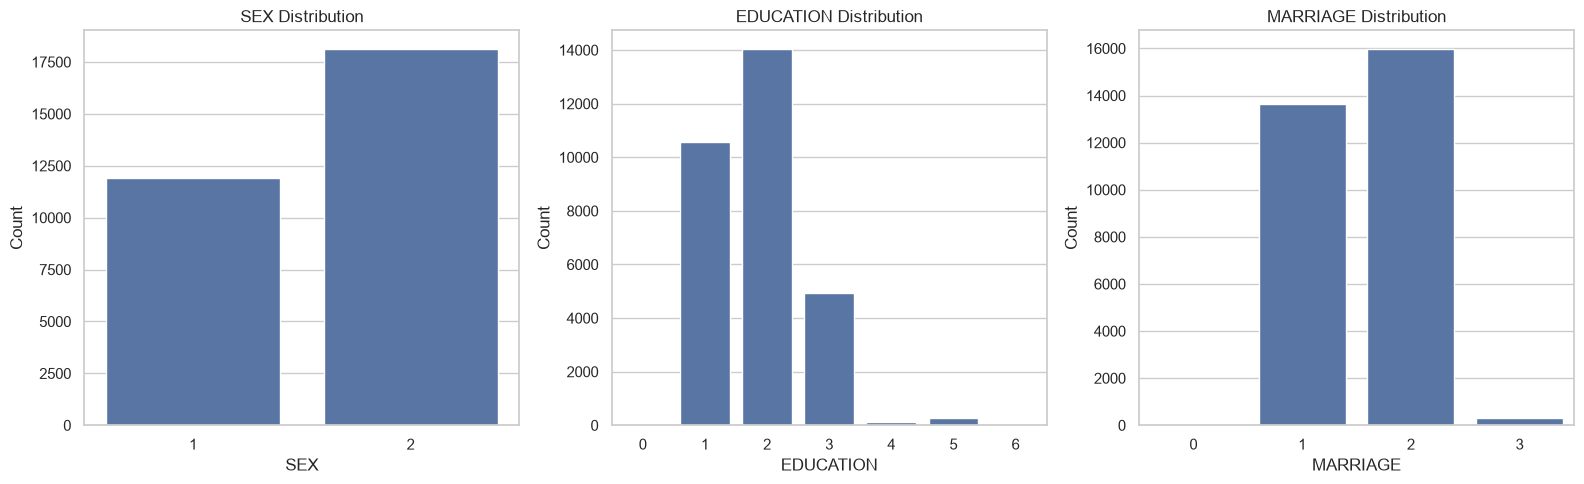

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

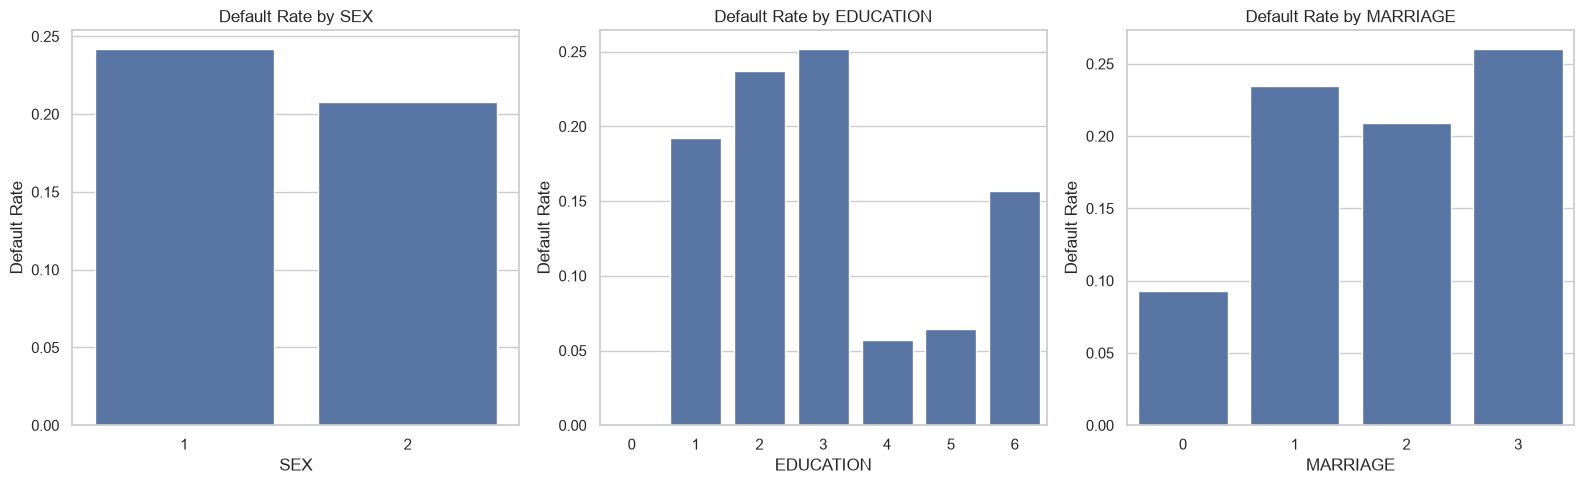

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, categorical_cols):
    sns.barplot(
        data=df,
        x=col,
        y=target,
        ax=ax,
        errorbar=None
    )
    ax.set_title(f"Default Rate by {col}")
    ax.set_ylabel("Default Rate")

plt.tight_layout()
plt.show()

### Categorical Feature Findings

- `SEX`, `EDUCATION`, and `MARRIAGE` contain a small number of discrete
  categories and should be treated as categorical variables rather than
  continuous numerical variables.
- Their category distributions are not uniform.
- Default rates show differences across categories for some variables,
suggesting that these features may contain useful predictive information.
- Rare categories should be investigated before deciding whether they
  should be retained, grouped, or otherwise encoded during preprocessing.

## 8. Numerical Feature Analysis

We examine the distributions of credit limit, age, bill amounts, and
payment amounts.

Histograms and boxplots are used to identify skewness, spread, and
potential extreme observations.

In [23]:
numerical_cols = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

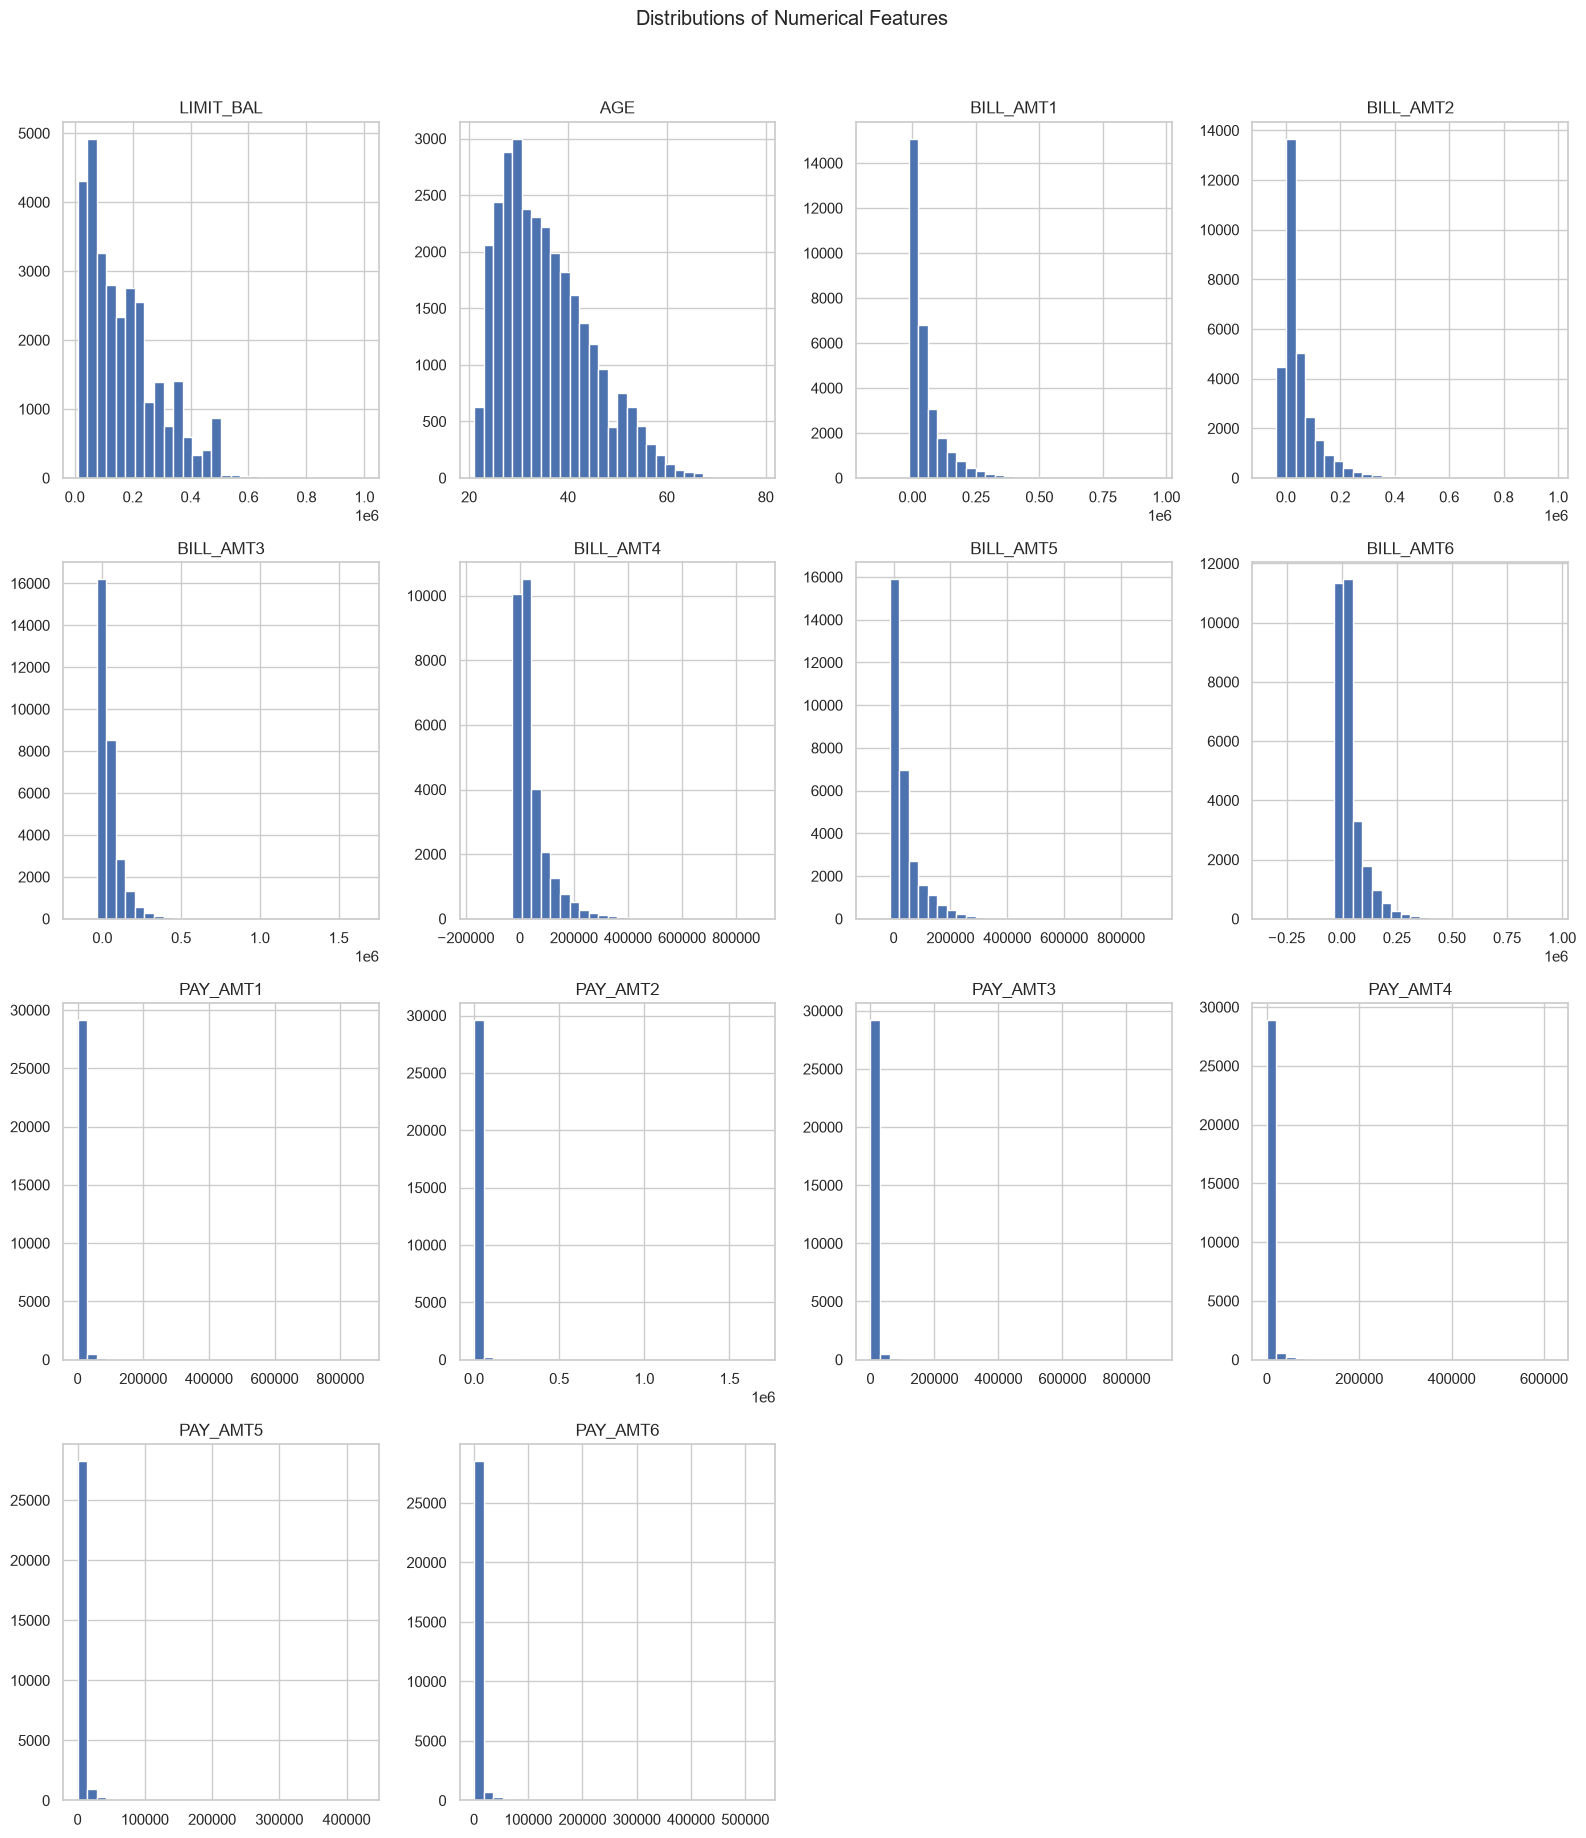

In [24]:
df[numerical_cols].hist(
    figsize=(16, 18),
    bins=30
)

plt.suptitle("Distributions of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

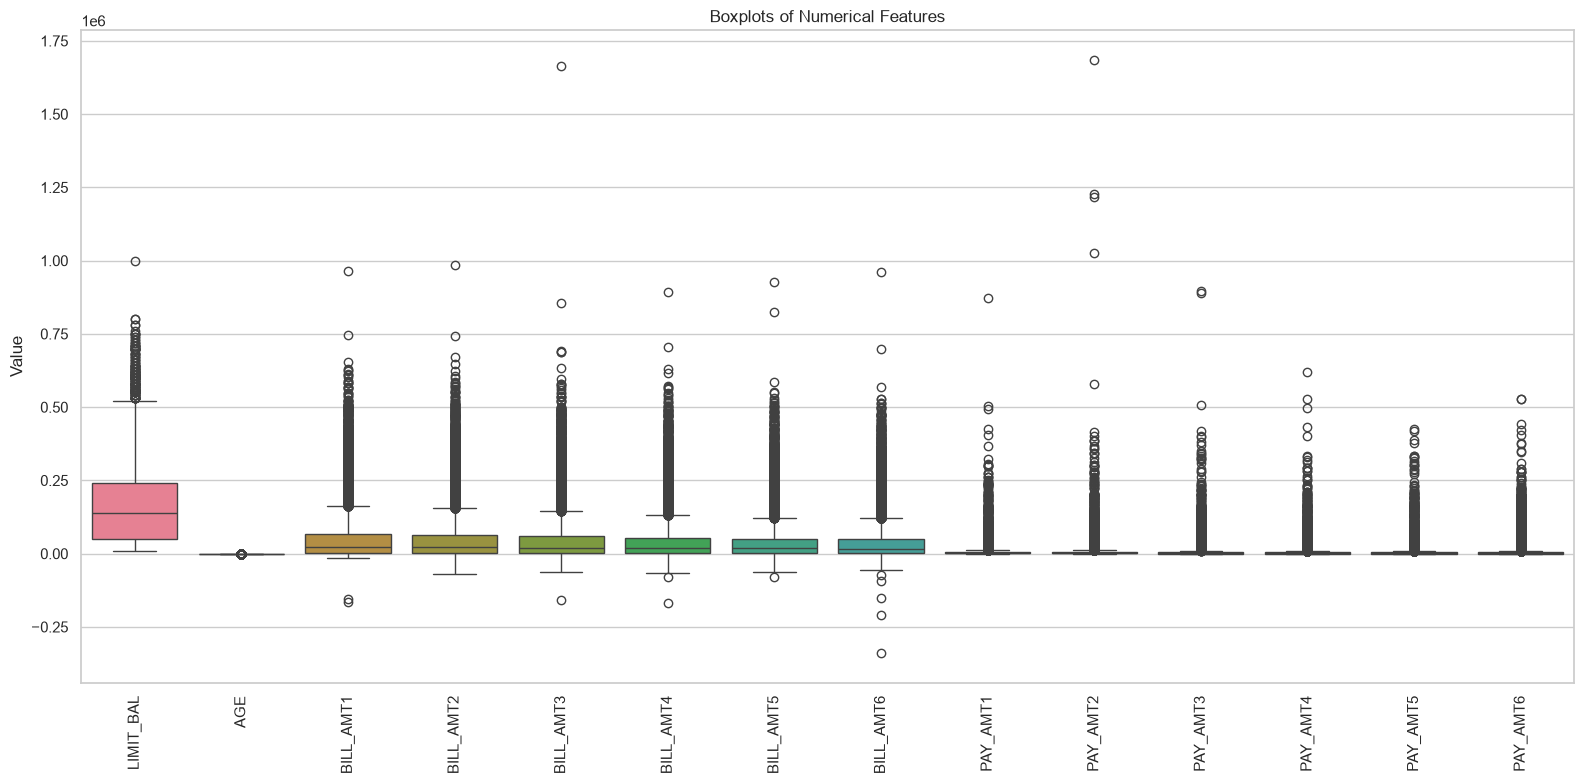

In [25]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df[numerical_cols])

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=90)
plt.ylabel("Value")

plt.tight_layout()
plt.show()

## 9. Repayment Status Analysis

The `PAY_*` variables represent repayment status across different
months. Although stored as integers, their values represent discrete
repayment-status categories.

We therefore analyze their category distributions rather than treating
them as ordinary continuous measurements.

In [26]:
pay_status_cols = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

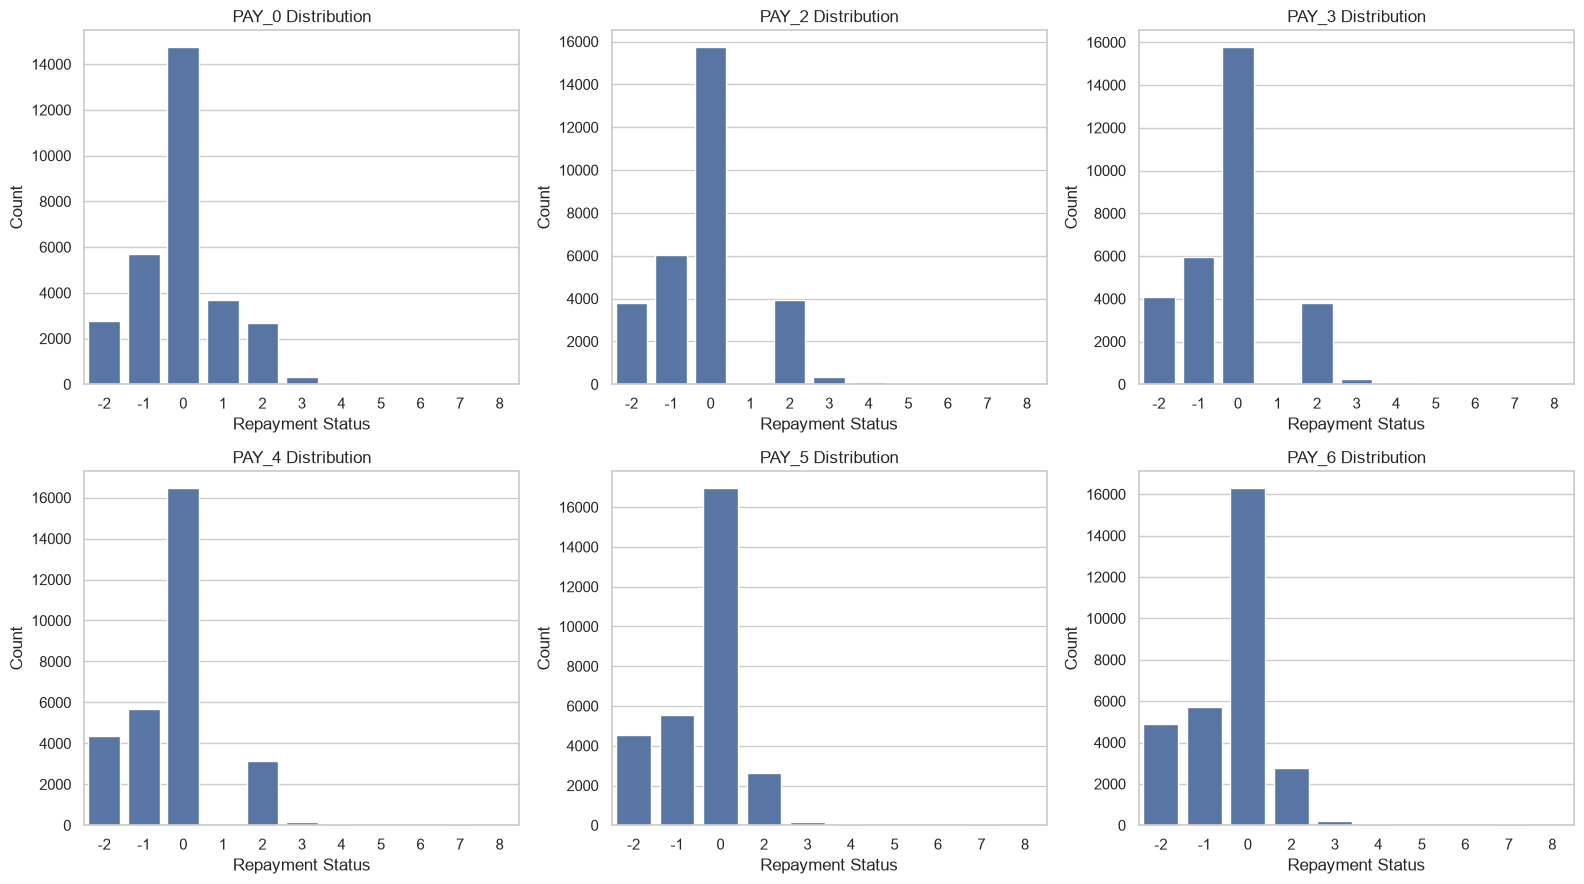

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, pay_status_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=ax,
        order=sorted(df[col].unique())
    )
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel("Repayment Status")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

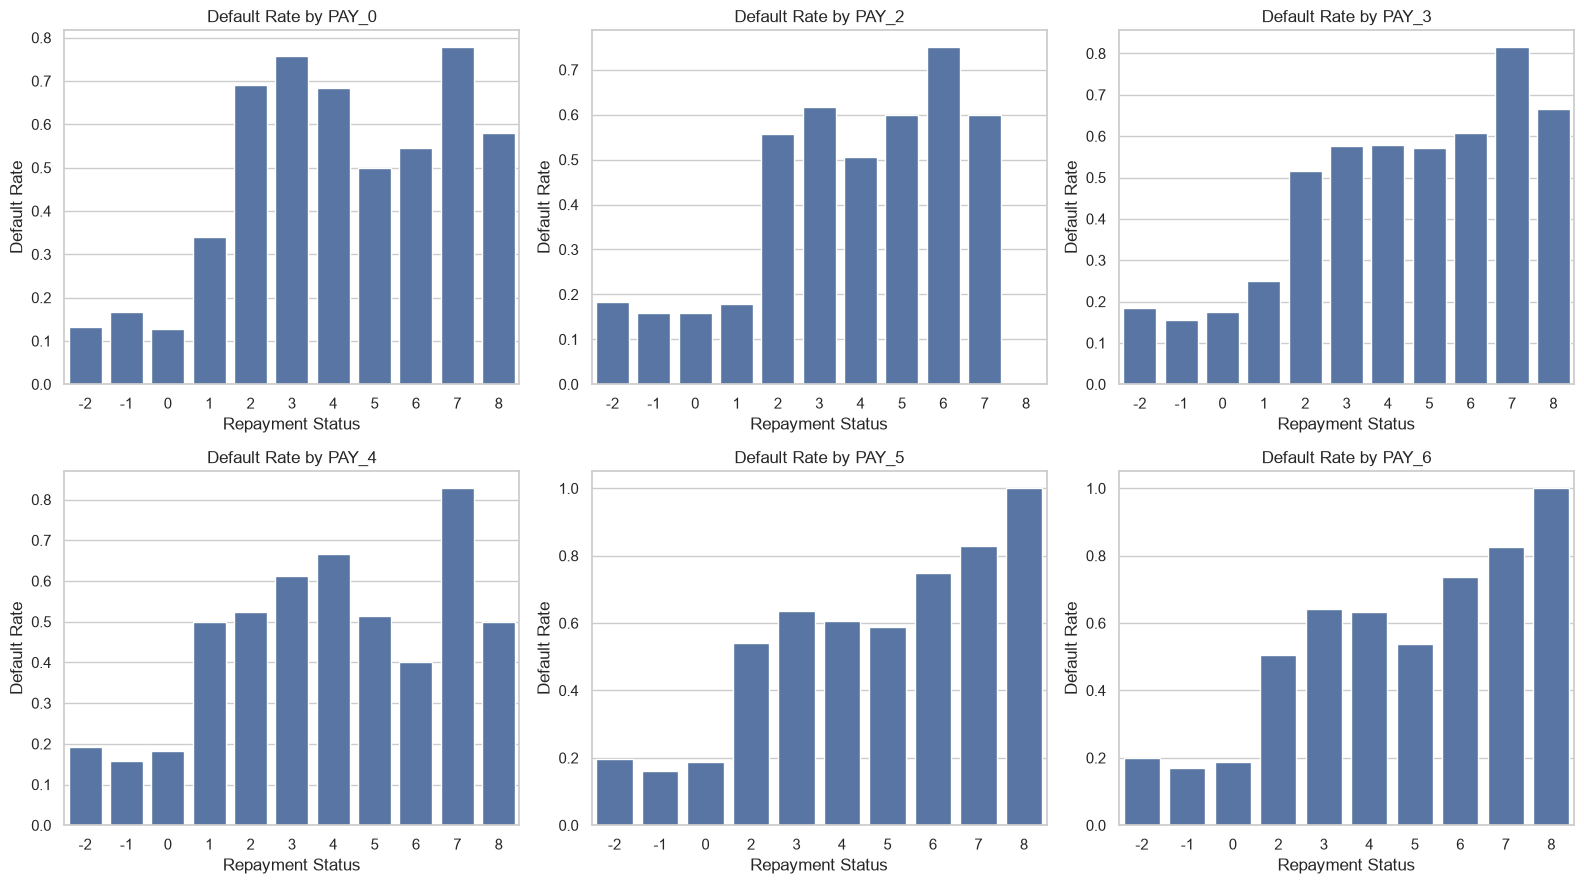

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, pay_status_cols):
    sns.barplot(
        data=df,
        x=col,
        y=target,
        ax=ax,
        errorbar=None
    )
    ax.set_title(f"Default Rate by {col}")
    ax.set_xlabel("Repayment Status")
    ax.set_ylabel("Default Rate")

plt.tight_layout()
plt.show()

### Default Rate by Repayment Status

To complement the visual analysis, we calculate the default rate for
each repayment-status category.

In [37]:
pay_default_rates = {}

for col in pay_status_cols:
    pay_default_rates[col] = df.groupby(col)[target].mean()

pay_default_rates_df = pd.DataFrame(pay_default_rates)

pay_default_rates_df

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,0.132294,0.182708,0.185312,0.192502,0.196876,0.200409
-1,0.167781,0.159669,0.155945,0.158959,0.161943,0.169861
0,0.128113,0.159123,0.174512,0.183288,0.188529,0.188444
1,0.339479,0.178571,0.250000,0.500000,NaN,NaN
2,0.691414,0.556150,0.515580,0.523267,0.541889,0.506508
3,0.757764,0.616564,0.575000,0.611111,0.634831,0.641304
4,0.684211,0.505051,0.578947,0.666667,0.607143,0.632653
5,0.500000,0.600000,0.571429,0.514286,0.588235,0.538462
6,0.545455,0.750000,0.608696,0.400000,0.750000,0.736842
7,0.777778,0.600000,0.814815,0.827586,0.827586,0.826087


## 10. Quick temporal view

We also have six months of repayment-status information.

### Note

Although the average repayment-status code is plotted for exploratory
purposes, the numeric mean should not be interpreted as a direct measure
of repayment severity because the `PAY_*` values are discrete status codes.
The category distributions and default rates are more informative for
preprocessing decisions.

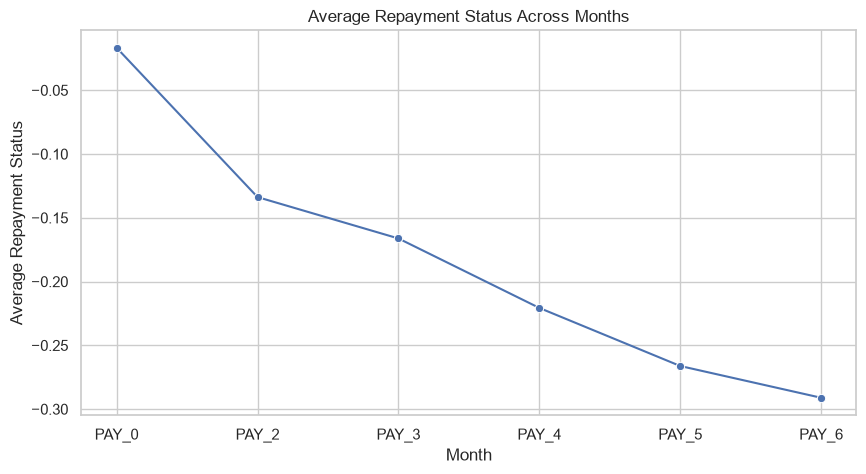

In [29]:
pay_means = df[pay_status_cols].mean()

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=pay_means.index,
    y=pay_means.values,
    marker="o"
)

plt.title("Average Repayment Status Across Months")
plt.xlabel("Month")
plt.ylabel("Average Repayment Status")

plt.show()

## 11. Bill and Payment Trends Across Months

The dataset contains monthly bill amounts and payment amounts. We examine
their aggregate behavior across months to identify temporal patterns and
potential feature-engineering opportunities.

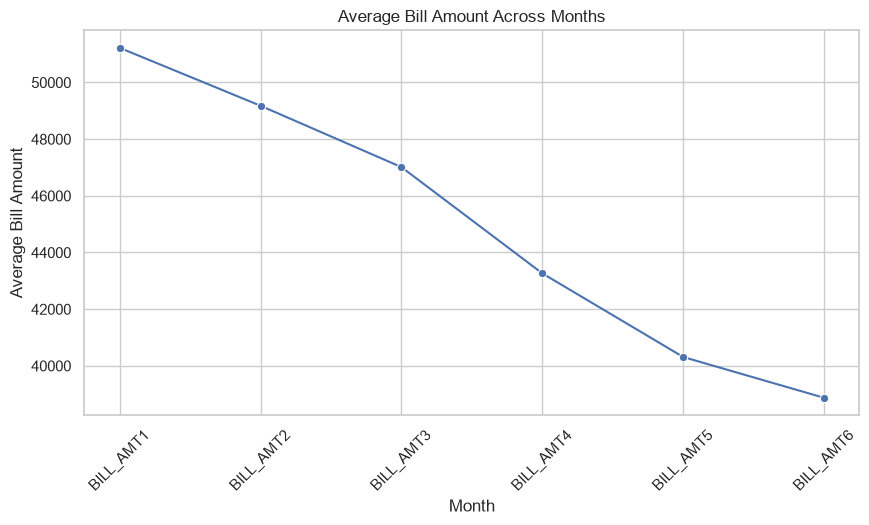

In [30]:
bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

bill_means = df[bill_cols].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=bill_means.index,
    y=bill_means.values,
    marker="o"
)

plt.title("Average Bill Amount Across Months")
plt.xlabel("Month")
plt.ylabel("Average Bill Amount")
plt.xticks(rotation=45)
plt.show()

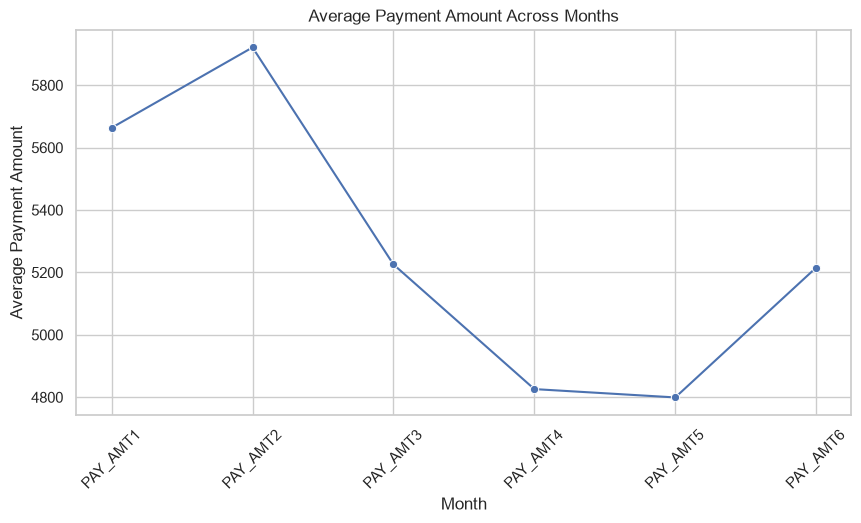

In [31]:
payment_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

payment_means = df[payment_cols].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=payment_means.index,
    y=payment_means.values,
    marker="o"
)

plt.title("Average Payment Amount Across Months")
plt.xlabel("Month")
plt.ylabel("Average Payment Amount")
plt.xticks(rotation=45)
plt.show()

## 12. Correlation Analysis

Correlation analysis is used to identify relationships among numerical
variables and potential redundancy between highly related features.

Correlation does not imply causation and is used here as an exploratory
tool rather than a basis for automatically removing features.

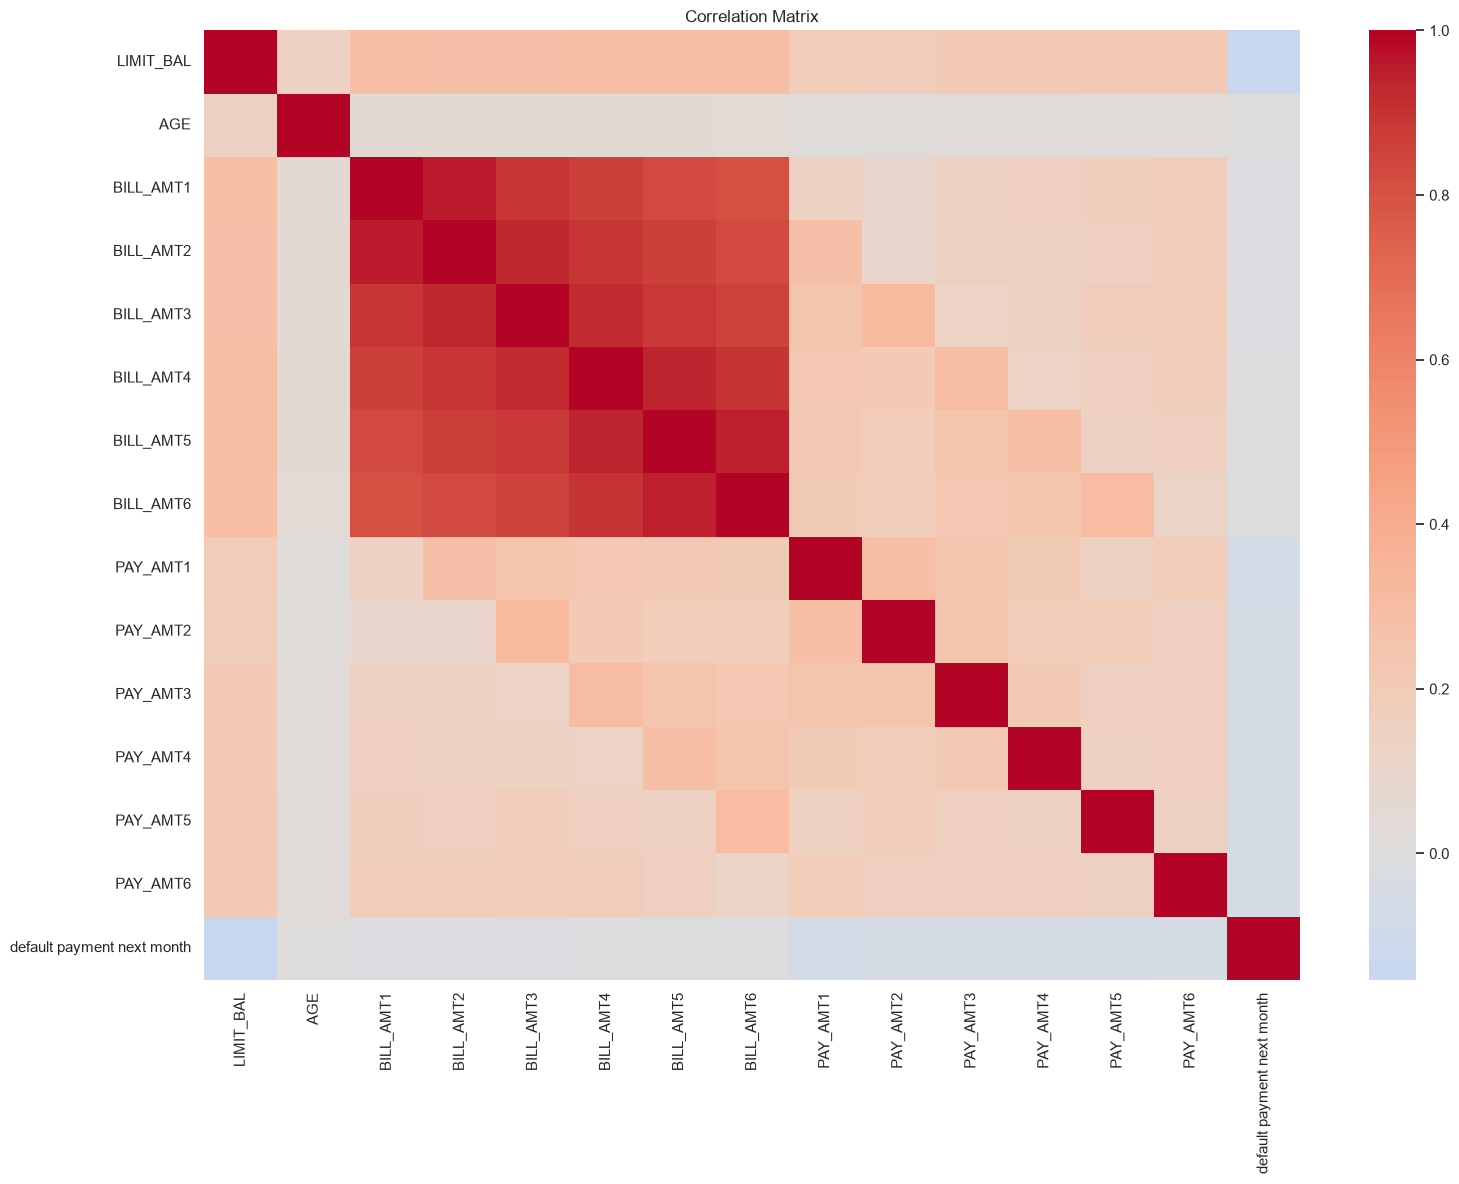

In [32]:
corr_cols = numerical_cols + [target]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [33]:
target_corr = (
    corr_matrix[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

target_corr

LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
AGE          0.013890
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
Name: default payment next month, dtype: float64

### Interpretation

The numerical features show relatively weak individual linear
correlations with the binary target. This does not imply that the
features are unimportant for prediction, since nonlinear relationships,
categorical effects, temporal behavior, and interactions may also
contribute to model performance.

## 13. Feature vs Target Analysis

The relationship between selected numerical features and the target
variable is examined using boxplots.

The features with the strongest absolute correlation with the target
are selected for exploratory visualization. This analysis helps us
understand whether their distributions differ between customers who
defaulted and those who did not.

Correlation alone is not sufficient to determine feature importance,
so these visualizations are used only for exploratory analysis.

In [34]:
top_features = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()

print("Top 4 numerical features by absolute correlation with target:")
print(top_features)

Top 4 numerical features by absolute correlation with target:
['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT4']


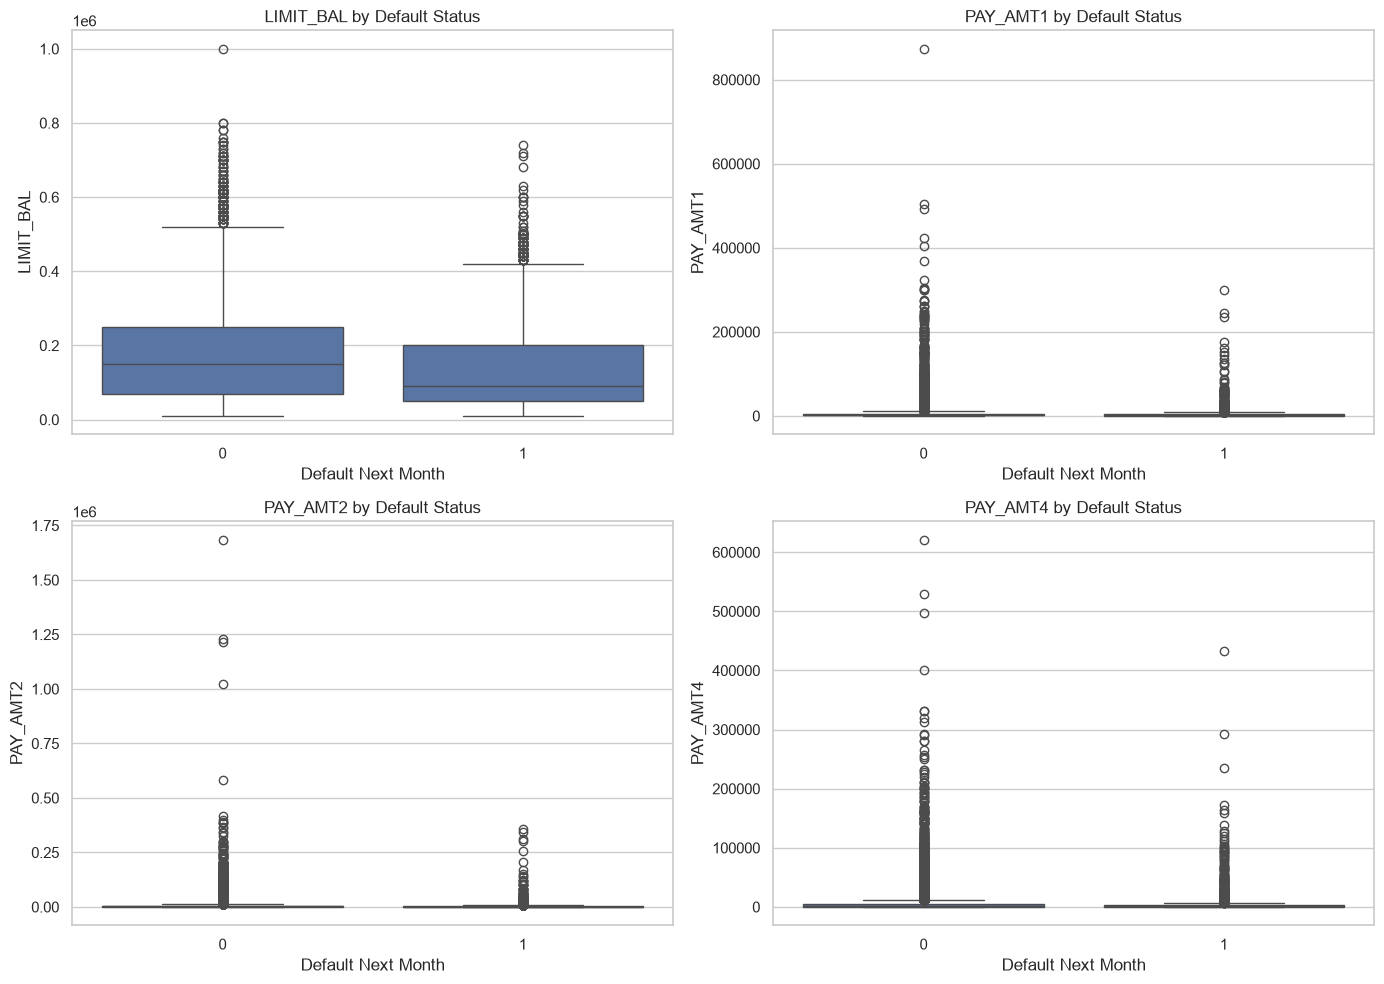

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, top_features):
    sns.boxplot(
        data=df,
        x=target,
        y=col,
        ax=ax
    )
    ax.set_title(f"{col} by Default Status")
    ax.set_xlabel("Default Next Month")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## 14. Outlier Analysis

Potential outliers are identified using the IQR rule. These observations
are not automatically removed because extreme financial values may
represent legitimate customers rather than data errors.

In [36]:
outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count,
        "outlier_percentage": count / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "outlier_percentage",
    ascending=False
)

,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
11,PAY_AMT4,-5279.875,9589.125,2994,9.980000
13,PAY_AMT6,-5705.625,9823.375,2958,9.860000
12,PAY_AMT5,-5416.000,9700.000,2945,9.816667
8,PAY_AMT1,-5009.000,11015.000,2745,9.150000
6,BILL_AMT5,-70878.250,122831.750,2725,9.083333
9,PAY_AMT2,-5417.500,11250.500,2714,9.046667
7,BILL_AMT6,-70657.375,121111.625,2693,8.976667
5,BILL_AMT4,-75942.125,132774.875,2622,8.740000
10,PAY_AMT3,-5782.500,10677.500,2598,8.660000
4,BILL_AMT3,-83581.500,146412.500,2469,8.230000


## 15. EDA Conclusions

### Dataset Quality

- The dataset contains 30,000 observations and 25 columns.
- No missing values were observed.
- No exact duplicate records were found.
- All variables are currently stored as integer types, but several are
  categorical variables represented using numeric codes.

### Target Variable

- The target is `default payment next month`.
- Approximately 77.88% of observations belong to the non-default class.
- Approximately 22.12% belong to the default class.
- The dataset therefore has moderate class imbalance.

### Categorical Variables

- `SEX`, `EDUCATION`, and `MARRIAGE` should be treated as categorical
  variables rather than continuous numerical variables.
- Rare categories should be considered during preprocessing.

### Repayment Status

- `PAY_0` through `PAY_6` represent repayment-status information over
  multiple months.
- These variables contain discrete status codes and should not be
  blindly treated as ordinary continuous variables.
- Their temporal structure provides useful information for feature
  engineering.

### Numerical Variables

- `LIMIT_BAL`, `BILL_AMT*`, and especially `PAY_AMT*` show substantial
  spread and skewness.
- Several variables contain extreme observations.
- Extreme values should not automatically be removed because they may
  represent legitimate financial behavior.

### Temporal Behavior

- Bill and payment variables provide six-month behavioral information.
- Aggregated and trend-based features may capture customer payment
  behavior more effectively than individual monthly values.

### Implications for Preprocessing and Feature Engineering

The EDA suggests that preprocessing should:

1. Remove the identifier `ID` from model features.
2. Preserve the raw dataset unchanged.
3. Handle categorical variables appropriately.
4. Treat repayment-status variables according to their categorical/
   ordinal semantics.
5. Evaluate whether transformations or robust scaling are appropriate for
highly skewed financial variables during preprocessing.
6. Avoid blindly removing extreme financial observations.
7. Create meaningful aggregate and temporal behavioral features.